In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

SEED = 12

# Parte 2: Modelos de Mezcla

Para esta parte se utilizó el dataset pizza_sales.csv, que contiene la información de ventas de pizzas.

In [3]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [4]:
pizza.describe()

,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000
mean,10701.479761,1.019622,16.494132,16.821474
std,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,9.750000,9.750000
25%,5337.000000,1.000000,12.750000,12.750000
50%,10682.500000,1.000000,16.500000,16.500000
75%,16100.000000,1.000000,20.250000,20.500000
max,21350.000000,4.000000,35.950000,83.000000


Al iniciar el análisis exploratorio, se observó que el dataset cuenta con 48.620 registros de ventas. La mayoría de los pedidos incluyen una sola pizza (`quantity` ≈ 1), con precios unitarios promedio cercanos a 16,5 y un máximo de 35,95. El precio total promedio (`total_price`) es de 16,8, aunque algunos pedidos alcanzan valores más altos al incluir varias pizzas o variedades de mayor costo.

Estos datos tienen una estructura de conteo, vamos a modelar las ventas por hora.

In [5]:
pizza['order_hour'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S').dt.hour
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')
pizza.head()

,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_hour
order_details_id,,,,,,,,,,,,
1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,11
2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,11
3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,11
4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,11
5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,11


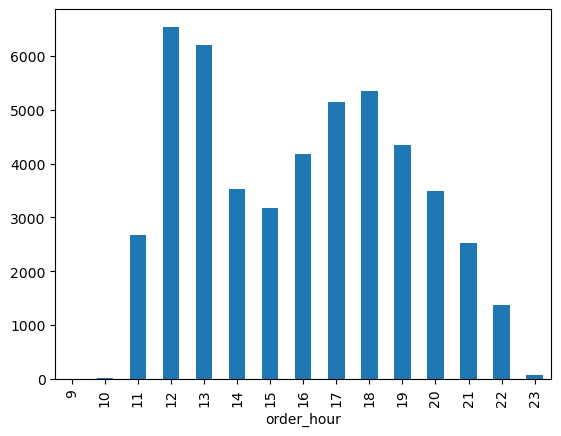

In [6]:
pizza.order_hour.value_counts().sort_index().plot(kind='bar');

Parece que tenemos outliers que sería mejor eliminar. Es claro que la pizzería trabaja de 11 a 23hs pero tenemos ordenes a las 9, 10 y 23.

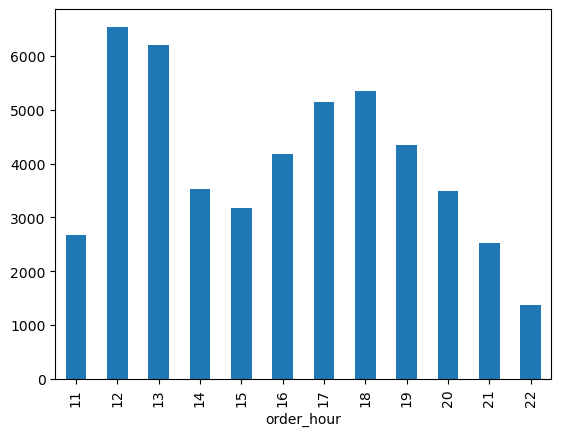

In [6]:
pizza.query('order_hour > 10 and order_hour < 23', inplace=True)

pizza.order_hour.value_counts().sort_index().plot(kind='bar');

Ahora tenemos que crear los _bins_

In [8]:
conteo = pizza.groupby(['order_date', 'order_hour']).size().reset_index(name='n_orders')
conteo

,order_date,order_hour,n_orders
0,2015-01-01,11,6
1,2015-01-01,12,17
2,2015-01-01,13,32
3,2015-01-01,14,15
4,2015-01-01,15,14
...,...,...,...
4141,2015-12-31,18,27
4142,2015-12-31,19,22
4143,2015-12-31,20,16
4144,2015-12-31,21,7


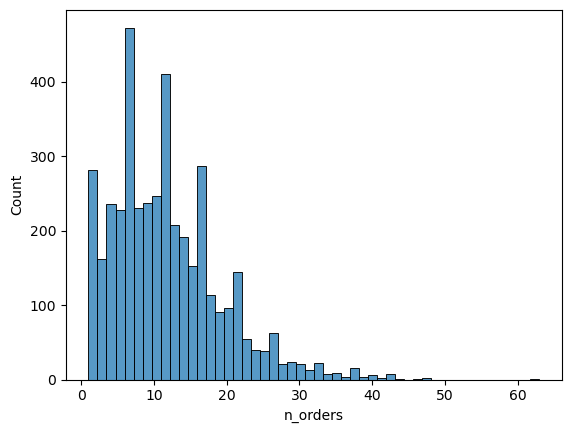

In [11]:
sns.histplot(conteo['n_orders'], bins=50);

## 1.
Plantear un modelo de mezcla finita (por ejemplo, mezcla de dos o más normales) y justificar la elección.

Son datos de conteo -> Poisson

Queremos saber cuanto se vende en horas pico y cuantas son.

Explicar eleccion de gamma

In [12]:
obs = conteo['n_orders'].values

In [13]:
k=2

with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=obs.mean(), sigma=obs.std(), shape=k)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 138 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Al correr el modelo con K = 2 se notó que los resultados no convergían bien, ya que los valores de R-hat eran mayores a 1. Esto indica un problema de identificabilidad: el modelo no logra diferenciar claramente qué componente corresponde a cada grupo, porque ambos pueden intercambiarse sin cambiar el resultado final.

## 2.
Analizar la identificabilidad del modelo y discutir posibles problemas de simetría entre componentes.

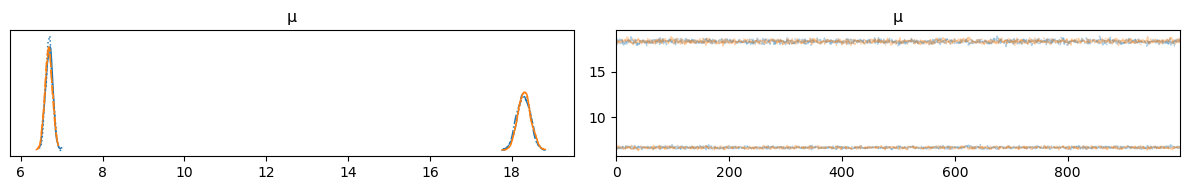

In [14]:
az.plot_trace(idata, var_names=['μ']);
plt.tight_layout();

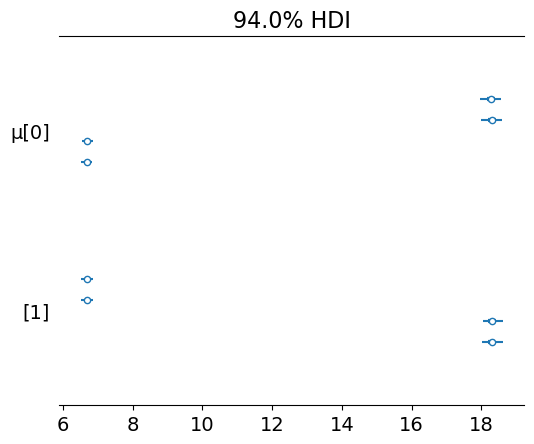

In [15]:
az.plot_forest(idata, var_names=['μ']);

Luego de analizar los gráficos, se observa que el modelo presenta problemas de identificabilidad, ya que los parámetros de los dos componentes se superponen y muestran simetría. En particular, las cadenas no convergen bien (la naranja se superpone con la azul y viceversa), lo que indica que el modelo no logra distinguir correctamente los grupos. Para solucionarlo, se usaron priors más informativos, asignando medias iniciales distintas (3 y 22). También se ordenaron los priors.

In [17]:
μ_μ = np.quantile(obs, np.linspace(0.1, 0.9, k))
μ_μ

array([ 3., 22.])

In [21]:
k=2

with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=μ_μ, sigma=5, shape=k, transform=pm.distributions.transforms.ordered)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 166 seconds.


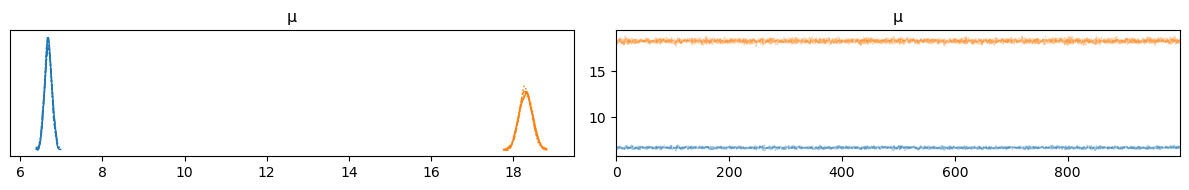

In [22]:
az.plot_trace(idata, var_names=['μ'])
plt.tight_layout();

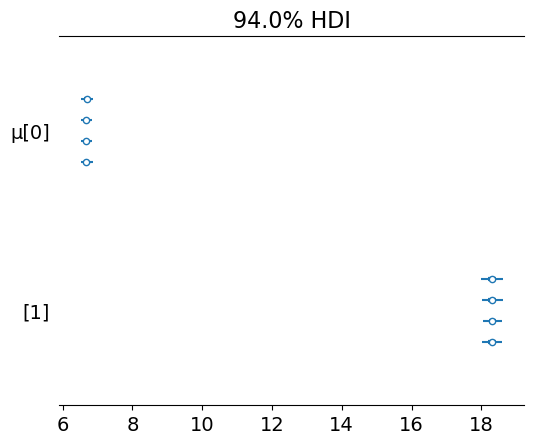

In [23]:
az.plot_forest(idata, var_names=['μ']);

In [24]:
az.summary(idata, kind="diagnostics")

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],0.002,0.001,1838.0,2012.0,1.0
μ[1],0.003,0.002,3158.0,2940.0,1.0
w[0],0.000,0.000,2100.0,2295.0,1.0
w[1],0.000,0.000,2100.0,2295.0,1.0


## 3.
Comparar distintos valores de K (número de componentes) y evaluar cuál describe mejor los datos.

Se procedió a evaluar distintos valores de K para analizar cómo variaba el ajuste del modelo.

> PROBAR CON MÁS Ks

In [25]:
Ks = [2, 3, 4, 5, 6]

idatas = []
modelos = []

for k in Ks:
    μ_μ = np.quantile(obs, np.linspace(0, 1, k))
    
    with pm.Model() as poisson_mixture_model:
        μ = pm.Gamma('μ', mu=μ_μ, sigma=5, shape=k, transform=pm.distributions.transforms.ordered)
        w = pm.Dirichlet('w', a=np.ones(k))

        comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

        x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

        idata = pm.sample(target_accept=0.95, idata_kwargs={"log_likelihood": True}, random_seed=SEED)

        idatas.append(idata)
        modelos.append(poisson_mixture_model)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 199 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 298 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 467 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 668 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1183 seconds.


In [26]:
az.summary(idatas[0])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],6.736,0.091,6.568,6.903,0.002,0.002,1386.0,1774.0,1.0
μ[1],18.459,0.162,18.162,18.764,0.003,0.002,2641.0,2772.0,1.0
w[0],0.574,0.011,0.553,0.593,0.000,0.000,1824.0,1808.0,1.0
w[1],0.426,0.011,0.407,0.447,0.000,0.000,1824.0,1808.0,1.0


In [27]:
az.summary(idatas[1])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],4.944,0.115,4.730,5.159,0.003,0.002,1824.0,2104.0,1.0
μ[1],13.160,0.213,12.740,13.535,0.004,0.003,2486.0,2606.0,1.0
μ[2],26.108,0.475,25.249,27.049,0.009,0.007,2748.0,2967.0,1.0
w[0],0.363,0.014,0.338,0.389,0.000,0.000,2255.0,2341.0,1.0
w[1],0.517,0.012,0.495,0.539,0.000,0.000,2433.0,2597.0,1.0
w[2],0.120,0.010,0.103,0.139,0.000,0.000,2561.0,2458.0,1.0


In [28]:
az.summary(idatas[2])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],4.131,0.151,3.854,4.420,0.004,0.003,1682.0,2287.0,1.0
μ[1],10.511,0.351,9.859,11.162,0.008,0.006,1924.0,2212.0,1.0
μ[2],18.917,0.558,17.861,19.944,0.012,0.009,2160.0,2048.0,1.0
μ[3],33.510,1.035,31.545,35.432,0.020,0.016,2737.0,2951.0,1.0
w[0],0.264,0.017,0.232,0.295,0.000,0.000,1953.0,2395.0,1.0
w[1],0.450,0.017,0.416,0.480,0.000,0.000,2559.0,2726.0,1.0
w[2],0.252,0.021,0.213,0.291,0.000,0.000,1972.0,2358.0,1.0
w[3],0.035,0.006,0.024,0.046,0.000,0.000,2461.0,2402.0,1.0


In [29]:
az.summary(idatas[3])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],3.955,0.160,3.650,4.251,0.003,0.003,2744.0,2433.0,1.0
μ[1],9.879,0.377,9.234,10.654,0.007,0.006,2591.0,2141.0,1.0
μ[2],17.609,0.549,16.563,18.627,0.009,0.009,3588.0,2655.0,1.0
μ[3],30.274,0.866,28.643,31.858,0.013,0.018,4549.0,2853.0,1.0
μ[4],61.317,4.870,51.934,70.409,0.080,0.093,3872.0,2404.0,1.0
w[0],0.242,0.018,0.210,0.278,0.000,0.000,2753.0,2559.0,1.0
w[1],0.422,0.020,0.386,0.459,0.000,0.000,3976.0,3196.0,1.0
w[2],0.283,0.023,0.239,0.327,0.000,0.000,2979.0,3110.0,1.0
w[3],0.052,0.008,0.038,0.067,0.000,0.000,5254.0,3006.0,1.0
w[4],0.001,0.001,0.000,0.001,0.000,0.000,1613.0,1437.0,1.0


In [30]:
az.summary(idatas[4])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],3.428,0.278,2.917,3.949,0.007,0.006,1434.0,1617.0,1.00
μ[1],7.443,0.875,5.867,9.091,0.029,0.020,912.0,1183.0,1.00
μ[2],12.766,1.059,10.751,14.700,0.034,0.022,948.0,1310.0,1.00
μ[3],19.975,1.153,17.919,22.171,0.032,0.025,1303.0,1721.0,1.00
μ[4],32.001,1.168,29.734,34.142,0.022,0.017,2872.0,3076.0,1.00
μ[5],61.976,4.590,53.020,70.141,0.080,0.071,3302.0,2352.0,1.00
w[0],0.170,0.034,0.107,0.231,0.001,0.001,1149.0,1130.0,1.00
w[1],0.274,0.051,0.177,0.367,0.001,0.001,1219.0,1518.0,1.00
w[2],0.339,0.046,0.252,0.417,0.001,0.001,1198.0,1753.0,1.00
w[3],0.179,0.039,0.108,0.253,0.001,0.001,1055.0,1491.0,1.01


In [32]:
df_comp = az.compare({f'k={k}': idata for k, idata in zip(Ks, idatas)})
df_comp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
k=6,0,-13736.972709,9.578782,0.000000,9.794491e-01,47.001383,0.000000,False,log
k=5,1,-13744.773632,9.684640,7.800923,3.159330e-14,47.602252,3.219549,False,log
k=4,2,-13752.611525,9.828846,15.638816,4.298440e-03,48.560160,7.317041,False,log
k=3,3,-13851.791168,9.309758,114.818459,1.084391e-02,56.024719,19.746831,False,log
k=2,4,-14456.379510,7.761774,719.406801,5.408525e-03,91.564464,57.465368,False,log


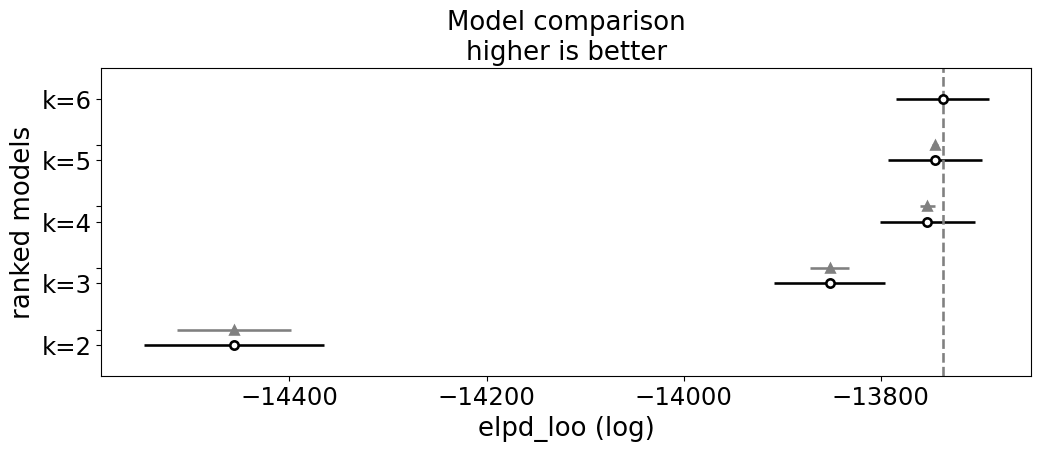

In [33]:
az.plot_compare(df_comp, figsize=(12, 4), plot_ic_diff=True);

los k más altos tienen mejores resultados. Ahora, nuestro objetivo es identificar horas pico y hay grupos con muy poco peso, quizás habría que quedarse con k=4

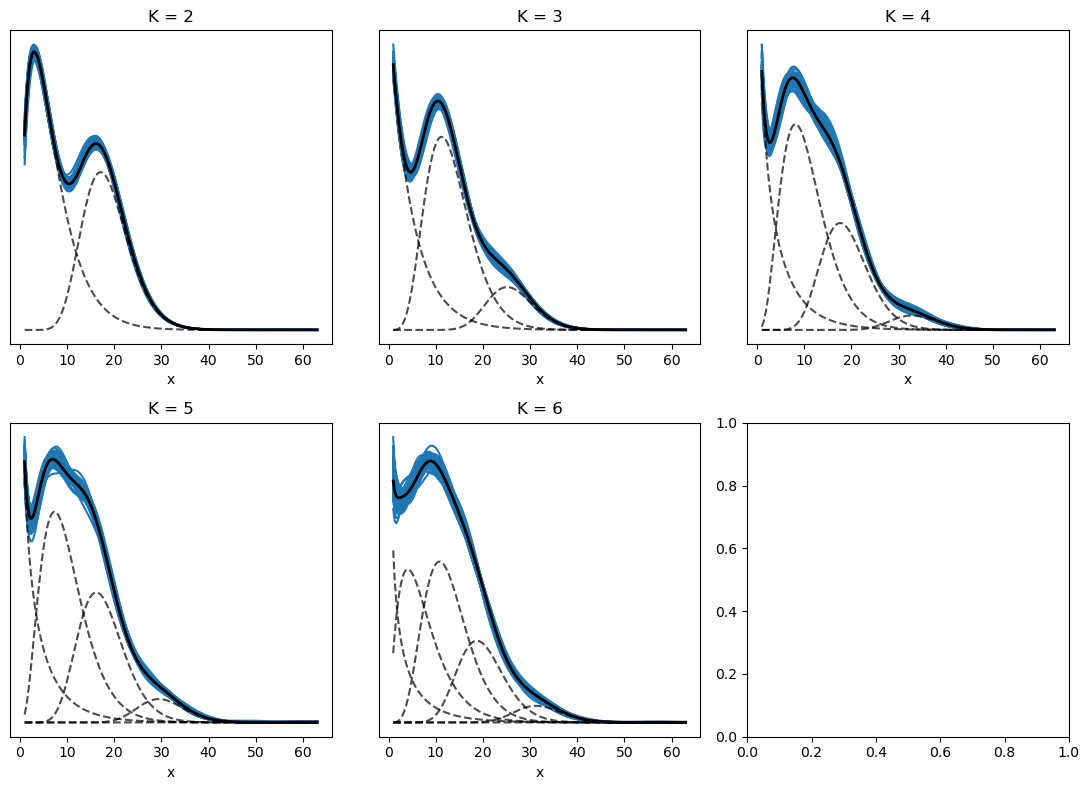

In [34]:
fig, ax = plt.subplots(2, 3, figsize=(11, 8))

ax = np.ravel(ax)
x = np.linspace(obs.min(), obs.max(), 200)
for idx, idata_x in enumerate(idatas):
    posterior_x = idata_x.posterior.stack(samples=("chain", "draw"))
    x_ = np.array([x] * Ks[idx]).T

    for i_ in np.random.randint(0, posterior_x.samples.size, size=50):
        dist = pz.Gamma(mu=posterior_x['μ'][:,i_], sigma=5)
        ax[idx].plot(x, np.sum(dist.pdf(x_) *  posterior_x['w'][:,i_].values, 1), 'C0')
 
    p_y = posterior_x['w'].mean("samples")
    dist = pz.Gamma(mu=posterior_x['μ'].mean("samples"), sigma=5)
    ax[idx].plot(x, np.sum(dist.pdf(x_) * p_y.values, 1), 'k', lw=2)
    ax[idx].plot(x, dist.pdf(x_) * p_y.values, 'k--', alpha=0.7)
         
    ax[idx].set_title('K = {}'.format(Ks[idx]))
    ax[idx].set_yticks([])
    ax[idx].set_xlabel('x')

plt.tight_layout();

In [35]:
for i, k in enumerate(Ks):
    modelo = modelos[i]
    idata = idatas[i]
    pm.sample_posterior_predictive(idata, model=modelo, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

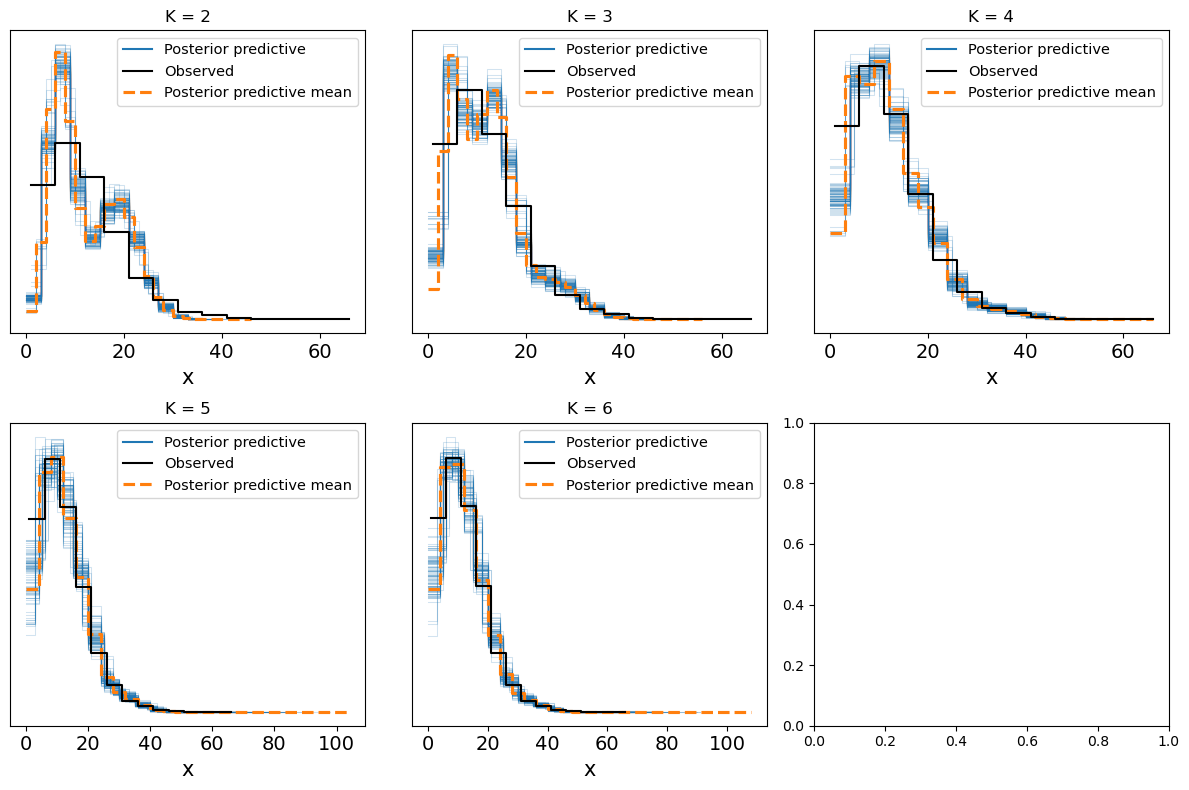

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes = np.ravel(axes)
for i, idata in enumerate(idatas):
    az.plot_ppc(idata, num_pp_samples=100, ax=axes[i])
    axes[i].set_title('K = {}'.format(Ks[i]))

plt.tight_layout();

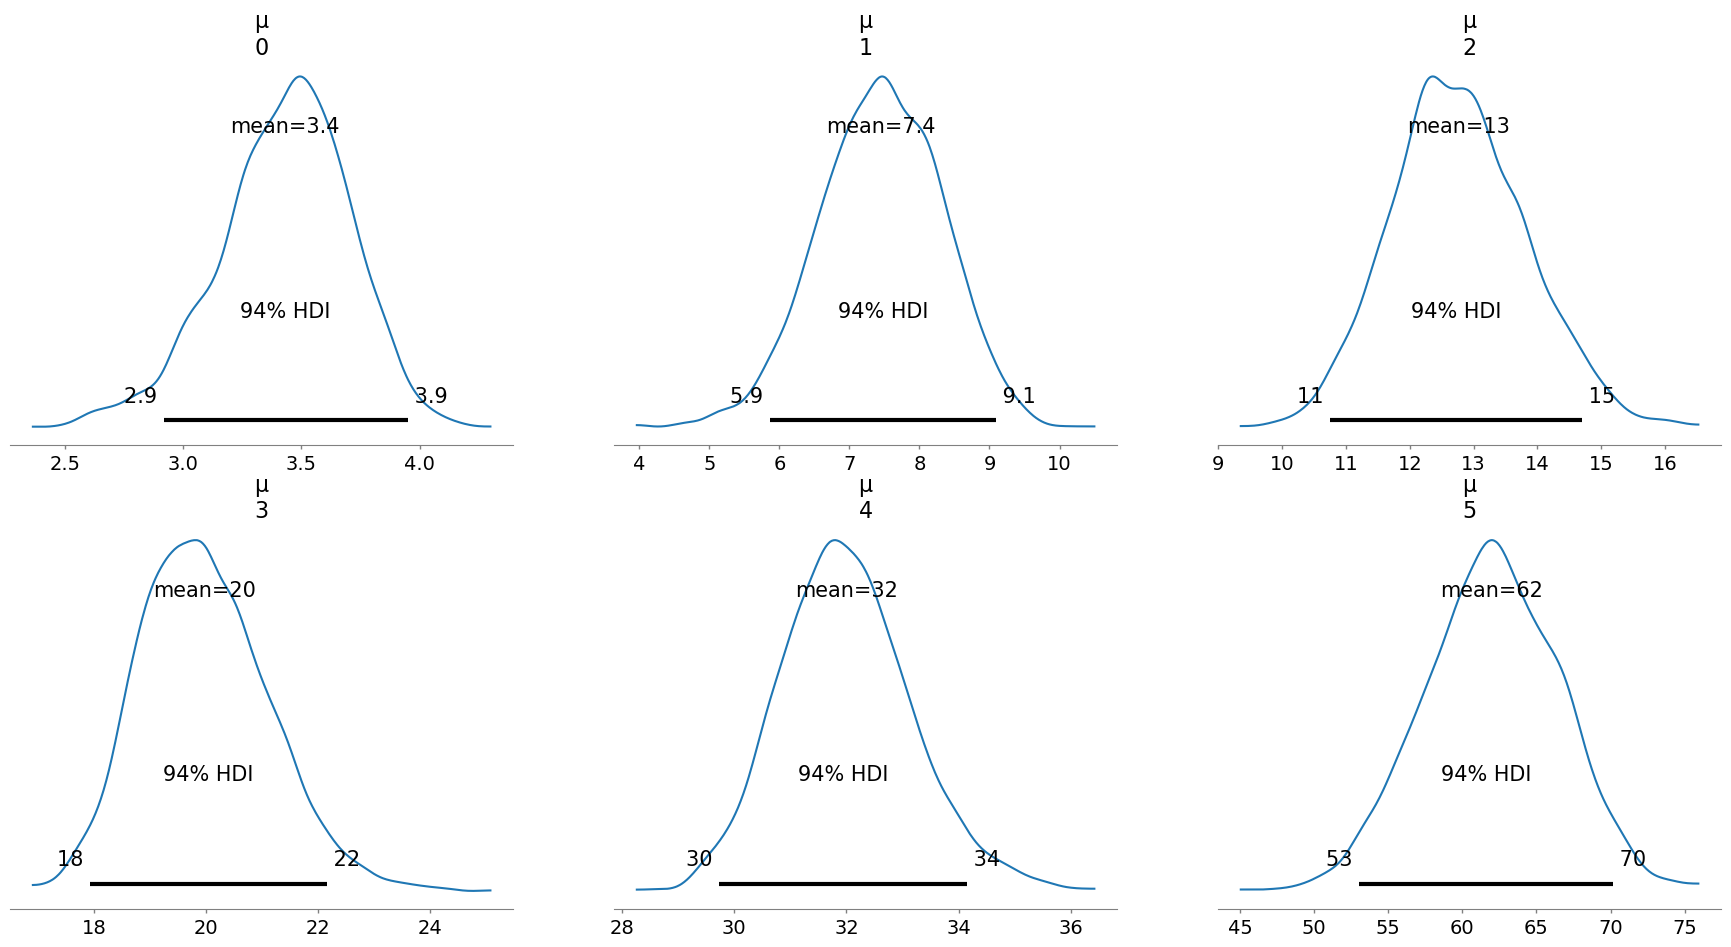

In [38]:
az.plot_posterior(idatas[4], var_names=['μ']);

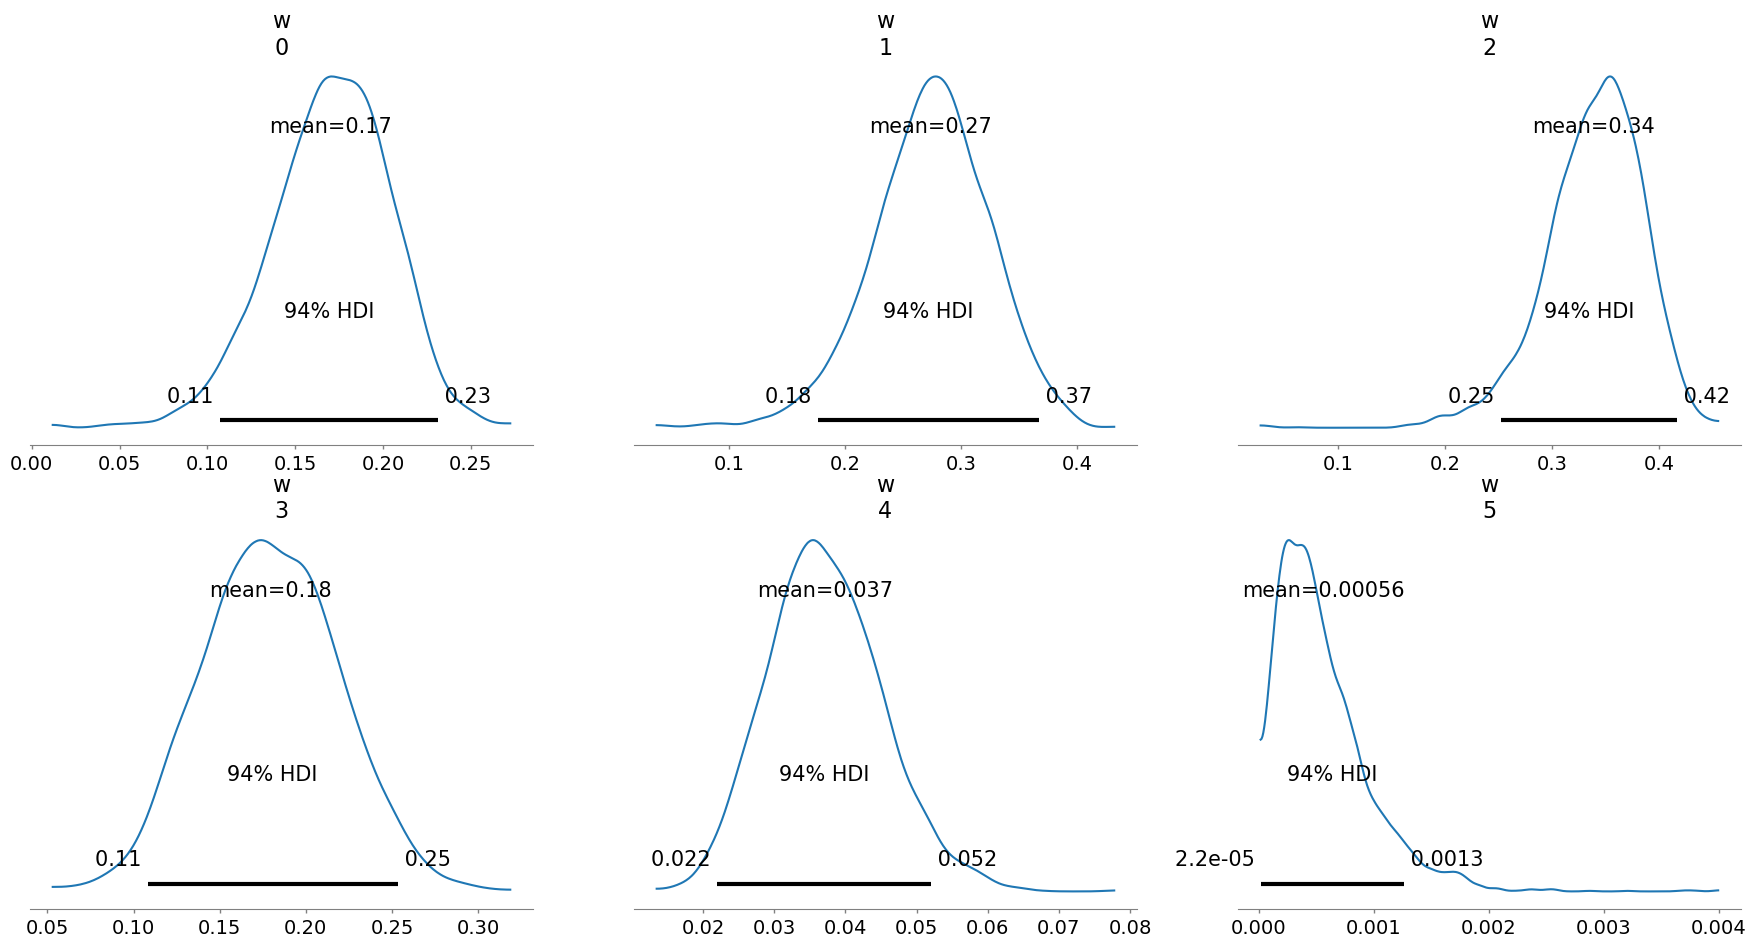

In [39]:
az.plot_posterior(idatas[4], var_names=['w']);

Me parece que los modelos con k=5 y k=6 ajustan demasiado (no sobreajustan, lo habríamos visto con el loo). Hay pesos muy pequeños, osea grupos insignificantes.

Ahora habría que hacer un modelo como de normales truncadas con k=4 (o más para probar), como lo que hicimos antes.

Esto con el objetivo de saber exactamente cuáles son las horas.

Lo que vimos hasta ahora nos dice que hay 5 (o 4) horas que describen los datos, cada una con una cantidad de ventas medias (mus)

In [7]:
pizza['order_time'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S')

pizza['order_time_continuous'] = (
    pizza['order_time'].dt.hour +
    pizza['order_time'].dt.minute / 60 +
    pizza['order_time'].dt.second / 3600
)

In [75]:
obs = np.random.choice(pizza['order_time_continuous'].values, size=1000)

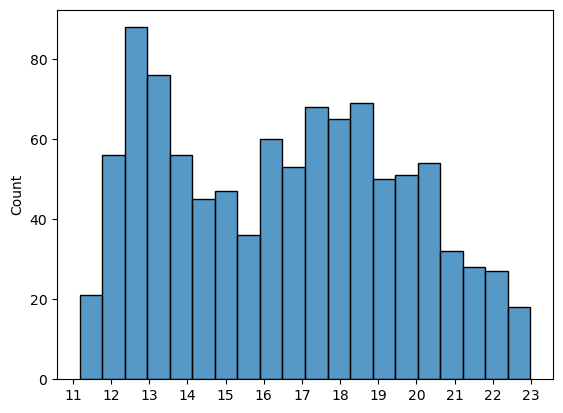

In [76]:
sns.histplot(obs, bins=20)
plt.xticks(range(11, 24));

In [77]:
k = 4

with pm.Model() as modelo:
    w = pm.Dirichlet('w', a=np.ones(k))
    μ = pm.TruncatedNormal(
        'μ',
        mu=[13, 16, 18, 20],
        sigma=1,
        lower=11,
        upper=23.0,
        shape=k
        )

    σ = pm.HalfNormal('σ', sigma=1, shape=k)

    comp_dists = [pm.TruncatedNormal.dist(mu=μ[i], sigma=σ[i], lower=11, upper=23.0) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comp_dists, observed=obs)

    idata = pm.sample(target_accept=0.95, random_seed=SEED, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 302 seconds.


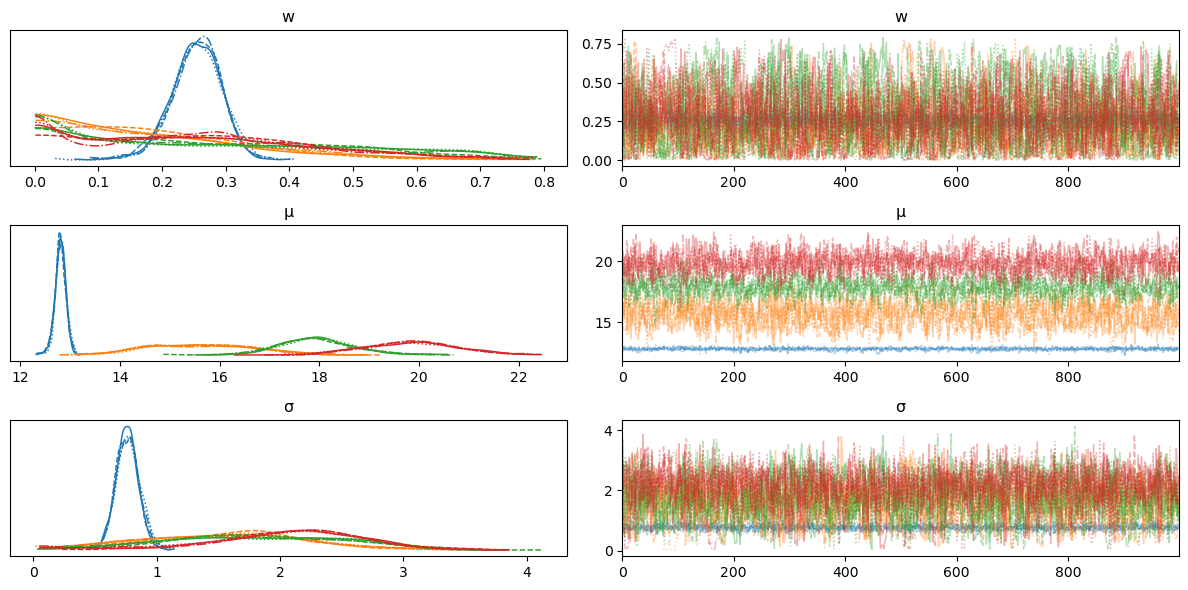

In [78]:
az.plot_trace(idata)
plt.tight_layout();

In [79]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w[0],0.254,0.040,0.176,0.323,0.001,0.001,1726.0,1711.0,1.00
w[1],0.198,0.155,0.000,0.477,0.006,0.006,533.0,530.0,1.00
w[2],0.287,0.214,0.000,0.661,0.010,0.004,474.0,869.0,1.00
w[3],0.261,0.177,0.000,0.573,0.007,0.004,525.0,671.0,1.00
μ[0],12.808,0.112,12.594,13.016,0.003,0.003,1338.0,1181.0,1.01
μ[1],15.636,1.045,13.799,17.555,0.038,0.021,768.0,835.0,1.01
μ[2],17.934,0.758,16.447,19.331,0.022,0.017,1144.0,1647.0,1.00
μ[3],19.831,0.909,18.076,21.451,0.025,0.018,1263.0,1045.0,1.00
σ[0],0.767,0.093,0.591,0.939,0.002,0.002,1397.0,1556.0,1.01
σ[1],1.556,0.656,0.284,2.681,0.026,0.015,634.0,646.0,1.00


In [80]:
with modelo:
    pm.sample_posterior_predictive(idata, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

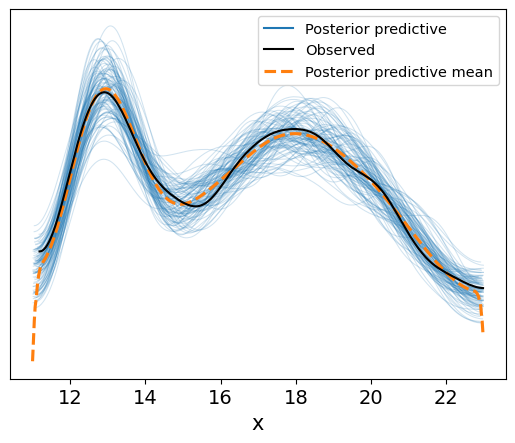

In [81]:
az.plot_ppc(idata, num_pp_samples=100);